In [71]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import os

In [72]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [74]:
full_dataset = torch.from_numpy(full_dataset)
full_dataset = full_dataset.to(torch.float32)

In [75]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.conv_ae_v2 import AE

checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "ae_conv_v2_train_date=26-02_13-37", "ae_conv_v2_ep60.pth"), map_location="cpu")

config = checkpoint["config"]

model = AE()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

AE(
  (encoder): Sequential(
    (0): Conv1d(1, 2, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(2, 4, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(4, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(8, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (10): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Conv1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (16): BatchNorm1d(32, eps=1e-05,

In [76]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model consists of", trainable_params, "trainable parameters.")

Model consists of 19347 trainable parameters.


In [77]:
# TODO: move it somewhere to autoencoders or sht
def score_points(pts, model, criterion=None):
    import torch
    if not criterion:
        import torch
        criterion = torch.nn.MSELoss()

    out_scores = []
    for out in pts:
        out = torch.tensor(out).to(torch.float32)
        out = out.reshape(1, 1, 96)
        pred = model(out).detach()
        loss = criterion(pred, out).detach().numpy()
        out_scores.append(loss)
        
    return out_scores

In [78]:
scores = score_points(full_dataset, model)

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_41028\2640477512.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(torch.float32)


In [79]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = model(data.reshape(1, 1, 96)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


In [80]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))

In [81]:
eval_score = score_points(eval_df['histogram'], model)

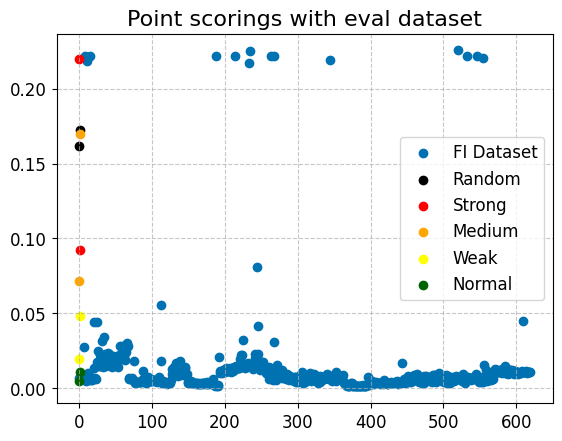

In [82]:
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.title("Point scorings with eval dataset")
plt.scatter(range(len(scores)), scores, label='FI Dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()

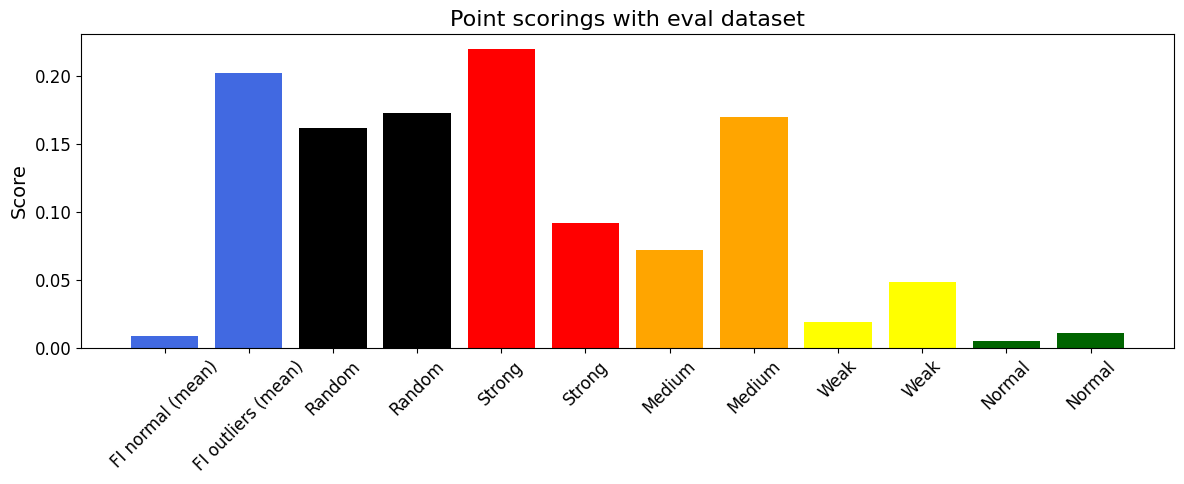

In [83]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.array(scores)
eval_score = np.array(eval_score)

fi_above = scores[scores > 0.055]
fi_below = scores[scores <= 0.055]

fi_above_mean = fi_above.mean() if len(fi_above) else 0
fi_below_mean = fi_below.mean() if len(fi_below) else 0

values = [fi_below_mean, fi_above_mean]
colors = ["royalblue", "royalblue"]
labels = ["FI normal (mean)", "FI outliers (mean)"]

group_colors = ["black", "red", "orange", "yellow", "darkgreen"]
group_labels = ["Random", "Strong", "Medium", "Weak", "Normal"]

for i in range(0, len(eval_score), 2):
    pair = eval_score[i:i+2]
    group_idx = i // 2
    
    for val in pair:
        values.append(val)
        colors.append(group_colors[group_idx])
        labels.append(group_labels[group_idx])

plt.figure(figsize=(12, 5))
plt.title("Point scorings with eval dataset")

x = np.arange(len(values))
plt.bar(x, values, color=colors)

plt.xticks(x, labels, rotation=45)
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [ ]:
pred = model(orig := torch.tensor(eval_df[eval_df['category'] == "strong"].iloc[1]['histogram']).to(torch.float32).reshape(1, 1, 96)).detach().squeeze()
loss = torch.nn.MSELoss()
loss(pred, orig)

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 1, 96])) that is different to the input size (torch.Size([96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(0.0921)

In [ ]:
sums = []
for hist in full_dataset:
    sums.append(np.sum(hist.numpy()))

np.float32(37.758514)

In [ ]:
out_sums = []
for out in eval_df['histogram']:
    out_sums.append(sum(out))

np.float64(47.816759049892426)

### This result suggests that sum of the histogram is not corellated with its score yet from the dataset perspective it may seem that

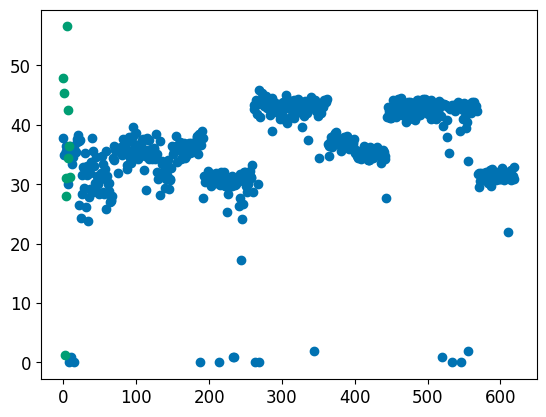

In [115]:
plt.scatter(range(len(sums)), sums)
plt.scatter(range(len(out_sums)), out_sums)
plt.show()